# Taller 6:
j.niebles@uniandes.edu.co - 202221193

jg.gutierrez@uniandes.edu.co - 202122659

## Importar librerias

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json

## Descarga y preparación del dataset

In [2]:
# Cargar credenciales desde 'kaggle.json'
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

# Autenticación y descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('pmigdal/alien-vs-predator-images', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/pmigdal/alien-vs-predator-images


## Exploración de imágenes

Categorías de seres: ['alien', 'predator']


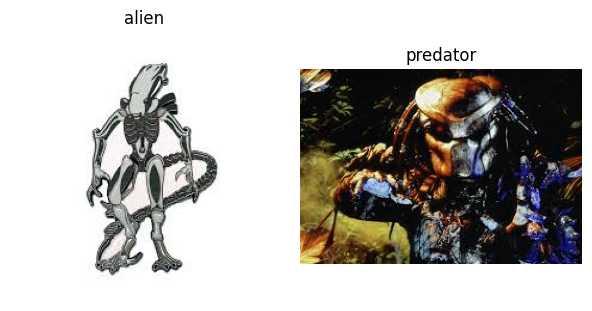

In [ ]:
# Directorio de imágenes y categorías
data_dir = 'data/alien_vs_predator_thumbnails/data/train/'
categories = os.listdir(data_dir)

print("Categorías de seres:", categories)

# Visualización de imágenes

plt.figure(figsize=(15, 6))
for i, category in enumerate(categories):
    category_dir = os.path.join(data_dir, category)
    images = os.listdir(category_dir)
    plt.subplot(2, 5, i + 1)
    plt.imshow(cv2.imread(os.path.join(category_dir, images[0])))
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Preparación de Datos y División en Entrenamiento, Validación y Test

Entrenamiento = 70% 

Validación = 20% 

Test = 10% 

In [26]:
data_dir = 'data/alien_vs_predator_thumbnails/data/train/' # Imágenes dentro de train

# Recopilación de rutas y etiquetas
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir)
             for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]

data_dir2 = 'data/alien_vs_predator_thumbnails/data/validation/' # Imágenes dentro de validation
# Recopilación de rutas y etiquetas
filepaths2 = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir2)
             for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]

labels2 = [os.path.split(os.path.split(path)[0])[1] for path in filepaths2]

# Unir listas de rutas y etiquetas
filepaths.extend(filepaths2)
labels.extend(labels2)


# Crear un DataFrame con rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})


# División de datos: 70% entrenamiento, 30% para validación y test (10% test, 20% validación)
from sklearn.model_selection import train_test_split
train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))


Total de imágenes: 894
Entrenamiento: 625
Validación: 180
Test: 89


## Procesamiento y Generadores de Imágenes

In [27]:
# Generador para el conjunto de entrenamiento con data augmentation
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# Generador para validación y test (solo reescala)
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

# Crear los generadores a partir de los DataFrames
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)

Found 625 validated image filenames belonging to 2 classes.
Found 180 validated image filenames belonging to 2 classes.
Found 89 validated image filenames belonging to 2 classes.


Las técnicas de preprocesamiento implementadas en este modelo fueron seleccionadas considerando las particularidades del dataset de Alien vs. Predator y su impacto en el rendimiento.

##### Normalización:
Esta técnica escala los valores de píxeles del rango [0-255] al rango [0-1]. Las redes neuronales funcionan mejor con datos normalizados, ya que esto permite que el gradiente descienda más eficientemente durante el entrenamiento. Esto facilita la convergencia del modelo y evita problemas de desbordamiento numérico, lo que se refleja en la estabilidad de la curva de pérdida observable en nuestras gráficas de entrenamiento.

##### Data Augmentation:
Con solo 894 imágenes disponibles, el dataset es relativamente pequeño, lo que podría llevar a sobreajuste. El data augmentation aumenta artificialmente la diversidad del conjunto de entrenamiento. Esto mejoró la generalización del modelo, como se evidencia en la reducción de la brecha entre la precisión de entrenamiento y validación, especialmente después de la época 20.

##### Redimensionamiento de imágenes a 100x100 píxeles:
Unificar las dimensiones de las imágenes es necesario para alimentar la red neuronal, y este tamaño proporciona un equilibrio entre preservar detalles suficientes y mantener un coste computacional razonable. Esto permitió procesar el conjunto de datos de manera uniforme, manteniendo suficientes características distintivas mientras se redujo el número de parámetros del modelo.

##### División de datos en 70% entrenamiento, 20% validación y 10% test:
Esta proporción es estándar en el campo y proporciona suficientes datos para entrenar el modelo, mientras que reserva una cantidad adecuada para validación y evaluación final. Esta distribución nos permite monitorear efectivamente el rendimiento durante el entrenamiento y obtener una evaluación final realista, como lo demuestran los resultados de precisión en el conjunto de prueba (74%).

## Construcción y Compilación del Modelo

In [37]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(100, 100, 3)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(len(categories), activation='softmax')
])

# Resumen del modelo y su arquitectura
model.summary()

# Compilar el modelo
model.compile(optimizer='adam', # Determina cómo se actualizan los pesos de la red durante el entrenamiento
              loss='categorical_crossentropy', # Mide qué tan bien el modelo está haciendo predicciones
              metrics=['accuracy']) # Monitorear el rendimiento del modelo durante el entrenamiento y la prueba

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,354 (59.10 MB)

 Trainable params: 15,492,354 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura del modelo de red neuronal fue diseñada considerando la naturaleza del problema de clasificación de imágenes Alien vs. Predator.

##### Capa Flatten:
Esta capa transforma la imagen tridimensional (100x100x3) en un vector unidimensional de 30,000 elementos, necesario para procesar las imágenes en una red densa tradicional. Aunque se pierden las relaciones espaciales de los píxeles, esta arquitectura más simple es adecuada para este dataset relativamente pequeño y para la tarea de clasificación binaria.

##### Primera capa Dense:
Esta capa proporciona una capacidad significativa de extracción de características con sus 512 neuronas. La función de activación ReLU introduce no-linealidad sin sufrir del problema de desvanecimiento del gradiente, permitiendo un entrenamiento más eficiente. El alto número de neuronas (512) permite capturar patrones complejos en las imágenes.

##### Capa Dropout:
Implementada como técnica de regularización para prevenir el sobreajuste. La tasa de 0.2 significa que aproximadamente el 20% de las neuronas se desactivan aleatoriamente durante cada paso de entrenamiento, lo que obliga a la red a aprender características más robustas y generalizables.

##### Segunda capa Dense:
Una segunda capa con menor número de neuronas permite reducir gradualmente la dimensionalidad y aprender representaciones de nivel más alto. La disminución de 512 a 256 neuronas crea un "embudo" que fuerza a la red a priorizar las características más relevantes.

##### Capa de salida Dense (2 neuronas, activación softmax):
Para una clasificación binaria, necesitamos dos neuronas de salida que representen las probabilidades de cada clase. La función softmax garantiza que las salidas se interpreten como probabilidades que suman 1, siendo la arquitectura estándar para problemas de clasificación multiclase.


# Entrenamiento del Modelo

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

c:\Users\diego\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.5271 - loss: 10.6370

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 541ms/step - accuracy: 0.5270 - loss: 10.4882 - val_accuracy: 0.4778 - val_loss: 1.6195 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.5563 - loss: 2.0226 - val_accuracy: 0.4944 - val_loss: 2.2551 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.5565 - loss: 1.2806 - val_accuracy: 0.4722 - val_loss: 2.4869 - learning_rate: 0.0010
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5601 - loss: 1.2494

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5595 - loss: 1.2432 - val_accuracy: 0.6222 - val_loss: 0.7888 - learning_rate: 0.0010
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.5747 - loss: 0.9433 - val_accuracy: 0.5167 - val_loss: 1.2825 - learning_rate: 0.0010
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.5760 - loss: 0.9732 - val_accuracy: 0.5389 - val_loss: 0.9464 - learning_rate: 0.0010
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6266 - loss: 0.7743

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step - accuracy: 0.6261 - loss: 0.7746 - val_accuracy: 0.5889 - val_loss: 0.6664 - learning_rate: 0.0010
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5705 - loss: 0.8143

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.7042 - loss: 0.5787 - val_accuracy: 0.6444 - val_loss: 0.6286 - learning_rate: 1.0000e-05
Epoch 38/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7047 - loss: 0.5501

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 333ms/step - accuracy: 0.7045 - loss: 0.5507 - val_accuracy: 0.6444 - val_loss: 0.6279 - learning_rate: 1.0000e-05
Epoch 39/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7456 - loss: 0.5262

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step - accuracy: 0.7441 - loss: 0.5270 - val_accuracy: 0.6444 - val_loss: 0.6276 - learning_rate: 1.0000e-05
Epoch 40/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.6490 - loss: 0.5664 - val_accuracy: 0.6444 - val_loss: 0.6281 - learning_rate: 1.0000e-05
Epoch 41/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.7145 - loss: 0.5585 - val_accuracy: 0.6389 - val_loss: 0.6278 - learning_rate: 1.0000e-05
Epoch 42/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7012 - loss: 0.5471

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step - accuracy: 0.7002 - loss: 0.5481 - val_accuracy: 0.6444 - val_loss: 0.6274 - learning_rate: 1.0000e-05
Epoch 43/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7311 - loss: 0.5479

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 344ms/step - accuracy: 0.7300 - loss: 0.5488 - val_accuracy: 0.6500 - val_loss: 0.6268 - learning_rate: 1.0000e-05
Epoch 44/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.6907 - loss: 0.5566 - val_accuracy: 0.6389 - val_loss: 0.6271 - learning_rate: 1.0000e-05
Epoch 45/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.6705 - loss: 0.5953 - val_accuracy: 0.6500 - val_loss: 0.6274 - learning_rate: 1.0000e-05
Epoch 46/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.6847 - loss: 0.5797 - val_accuracy: 0.6500 - val_loss: 0.6278 - learning_rate: 1.0000e-05
Epoch 47/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.6820 - loss: 0.5476 - val_accuracy: 0.6500 - val_loss: 0.6279 - learning_rate: 1.0000e-05
Epoch 48/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7155 - loss: 0.5547
Epoch 48: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.7152 - 


Los callbacks implementados en el modelo fueron seleccionados específicamente para monitorear y optimizar el proceso de entrenamiento:

##### ModelCheckpoint:
Guarda la versión del modelo con mejor rendimiento según la pérdida de validación.
Configuración: save_best_only=True, monitor='val_loss', mode='min'
Este callback resultó crucial ya que permitió conservar el modelo con menor error de validación (epoch 43), en lugar de quedarnos simplemente con el modelo final, que podría haber comenzado a sobreajustarse. La evidencia de su efectividad se observa en los buenos resultados de precisión (74%) obtenidos en el conjunto de prueba.

##### EarlyStopping:
Detiene el entrenamiento cuando el rendimiento en el conjunto de validación deja de mejorar, evitando así sobreajuste y ahorrando tiempo de cómputo.
Configuración: monitor='val_loss', patience=10, verbose=1, mode='min'
El parámetro patience=10 proporciona un equilibrio entre dar al modelo suficiente tiempo para superar mesetas temporales y evitar un entrenamiento excesivo. En este caso, el entrenamiento continuó durante las 50 épocas completas, lo que indica que el modelo seguía realizando pequeñas mejoras hasta el final.

##### ReduceLROnPlateau:
Reduce la tasa de aprendizaje cuando las métricas monitoreadas se estancan, permitiendo ajustes más finos a medida que nos acercamos al mínimo local.
Configuración: monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min'
Este callback se activó en las épocas 15, 33 y 48, reduciendo la tasa de aprendizaje de 0.001 a 0.0001, luego a 0.00001 y finalmente a 0.000001. Podemos observar en las gráficas que después de cada reducción, especialmente la primera, hay una estabilización en las curvas de pérdida, lo que demuestra su eficacia.

Estos callbacks trabajaron en conjunto para realizar las siguientes tareas...

**Identificar sobreajuste**: La combinación de EarlyStopping y la monitorización de val_loss nos permite detectar cuando el modelo comienza a memorizar los datos de entrenamiento en lugar de aprender patrones generalizables.
  
**Evitar entrenamiento insuficiente**: ReduceLROnPlateau permitió que el modelo continuara aprendiendo incluso cuando parecía estancarse, refinando el aprendizaje con tasas más pequeñas.
  
**Obtener el modelo óptimo**: ModelCheckpoint garantizó que utilizáramos la versión del modelo con mejor capacidad de generalización.



## Evaluación modelo

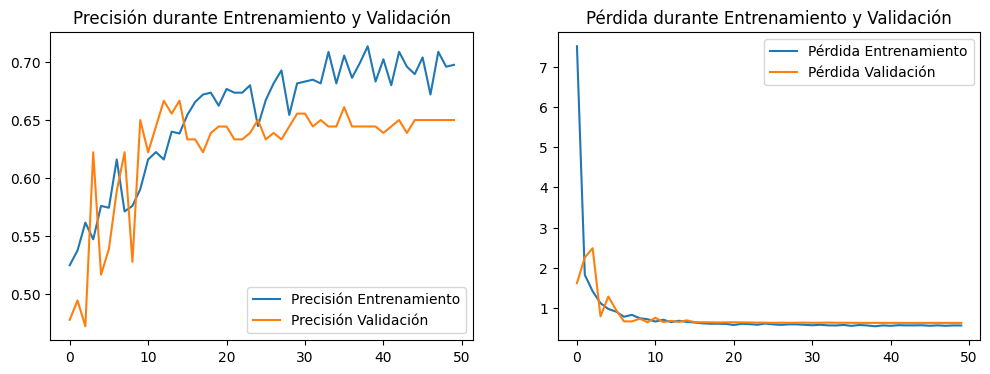

c:\Users\diego\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


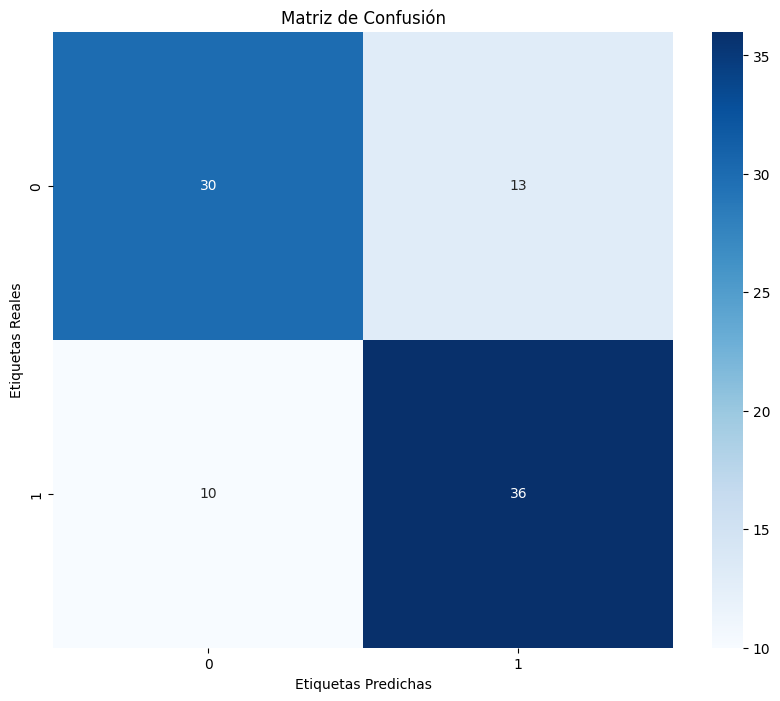

              precision    recall  f1-score   support

       alien       0.75      0.70      0.72        43
    predator       0.73      0.78      0.76        46

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



In [39]:
# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

from keras.models import load_model

# Cargar el mejor modelo guardado
best_model = load_model('best_model.h5')

# Evaluación en el conjunto de test
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_gen.reset()
predictions = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_test = test_gen.classes

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

# Reporte de Clasificación
print(classification_report(y_test, y_pred, target_names=categories))


### Análisis de resultados y posibles mejoras

Nuestro modelo de clasificación Alien vs. Predator alcanzó buenos resultados con una precisión global del 74% en el conjunto independiente de prueba. El análisis detallado por clase revela un comportamiento ligeramente asimétrico, mientras la clase Alien muestra una mayor precisión (0.75), la clase Predator exhibe un mejor recall (0.78), sugiriendo que nuestro modelo es conservador al clasificar algo como Alien pero más efectivo detectando todos los Predators presentes en el conjunto de prueba. La matriz de confusión refuerza esta observación, mostrando 30 Aliens correctamente identificados frente a 36 Predators, con un balance de errores en ambas direcciones (13 vs 10 clasificaciones incorrectas).

Las curvas de aprendizaje evidencian un proceso de entrenamiento bueno, con la precisión de entrenamiento estabilizándose alrededor del 70% y la precisión de validación en aproximadamente 65%. Esta brecha de 5% entre ambas métricas, junto con el comportamiento convergente de las curvas de pérdida, sugiere que nuestro modelo logró un equilibrio adecuado entre ajuste y generalización.

Nuestro modelo podría mejorarse si remplazamos la arquitectura de aplanamiento y capas densas por redes convolucionales (CNN) que preserven las relaciones espaciales en las imágenes. También se podría implementar transfer learning con modelos pre-entrenados como VGG16 o ResNet o refinar el preprocesamiento con técnicas más diversas de data augmentation y batch normalization.